In [1]:
from shutil import copy
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from glob import glob
import psi4
import sys
sys.path.insert(0, os.path.join(os.path.expanduser('~'),'DDLUCJ/check_amplitudes/'))
from helper_CC_ML_spacial import *
import networkx as nx

  Threads set to 12 by Python driver.


In [23]:
import pyscf
import pyscf.cc
import pyscf.mcscf

# Specify molecule properties
open_shell = False
spin_sq = 0
# === 1. Molecule Setup ===
struct_path = os.path.join(os.path.expanduser('~'),'DDLUCJ/check_amplitudes/diatomics/HLi.xyz')
with open(struct_path,'r') as f:
    text=f.read()

# Build N2 molecule
mol = pyscf.gto.Mole()
mol.verbose = 5

mol.build(
    atom=struct_path,
    basis="STO-3G",
    symmetry="c1",
    spin=int(text.split('\n')[1].split()[1])-1
)

# Define active space
n_frozen = 1

# active_space = list(range(cas.ncore,cas.ncore+cas.ncas))
active_space = range(n_frozen, mol.nao_nr())
print(active_space)
# Get molecular integrals
scf = pyscf.scf.RHF(mol).run()
num_orbitals = len(active_space)
n_electrons = int(sum(scf.mo_occ[active_space]))


num_elec_a = (n_electrons + mol.spin) // 2
num_elec_b = (n_electrons - mol.spin) // 2
cas = pyscf.mcscf.CASCI(scf, num_orbitals, (num_elec_a, num_elec_b))

active_space = list(range(cas.ncore,cas.ncore+cas.ncas))
mo = cas.sort_mo(active_space, base=0)
hcore, nuclear_repulsion_energy = cas.get_h1cas(mo)
hcore_pyscf = hcore
eri = pyscf.ao2mo.restore(1, cas.get_h2cas(mo), num_orbitals)

# Compute exact energy
casci_e = cas.run().e_tot
print("H1 shape:", hcore.shape)
print("ERI shape:", eri.shape)
print("Active electrons: (α, β) =", (num_elec_a, num_elec_b))
print("Exact (CCSD) Energy:", casci_e)

System: uname_result(system='Darwin', node='Griers-MacBook-Pro.local', release='23.6.0', version='Darwin Kernel Version 23.6.0: Thu Mar  6 22:00:07 PST 2025; root:xnu-10063.141.1.704.6~1/RELEASE_ARM64_T6030', machine='arm64')  Threads 1
Python 3.10.16 | packaged by conda-forge | (main, Dec  5 2024, 14:20:01) [Clang 18.1.8 ]
numpy 1.26.4  scipy 1.15.2  h5py 3.13.0
Date: Fri Jun  6 13:54:26 2025
PySCF version 2.8.0
PySCF path  /Users/grierjones/miniconda3/envs/psi4/lib/python3.10/site-packages/pyscf

[CONFIG] conf_file None
[INPUT] verbose = 5
[INPUT] max_memory = 4000 
[INPUT] num. atoms = 2
[INPUT] num. electrons = 4
[INPUT] charge = 0
[INPUT] spin (= nelec alpha-beta = 2S) = 0
[INPUT] symmetry C1 subgroup None
[INPUT] Mole.unit = angstrom
[INPUT] Symbol           X                Y                Z      unit          X                Y                Z       unit  Magmom
[INPUT]  1 H      0.000000000000   0.000000000000  -1.389682265622 AA    0.000000000000   0.000000000000  -2.626118

array([[ 4.60100588e-03,  5.48458339e-01, -1.39389691e-01,
         2.39020017e-17, -1.13772076e-17,  1.19028897e+00],
       [ 9.91239569e-01, -1.67794902e-01, -2.09905392e-01,
         2.36949088e-17, -2.58611683e-17,  9.21431506e-02],
       [ 3.26459732e-02,  4.54296516e-01,  7.99700704e-01,
        -9.61505494e-17,  9.08713173e-17, -7.06970282e-01],
       [-0.00000000e+00,  0.00000000e+00,  1.11022302e-16,
         8.50650808e-01, -5.25731112e-01, -0.00000000e+00],
       [-0.00000000e+00,  3.85185989e-34,  4.93038066e-32,
         5.25731112e-01,  8.50650808e-01, -0.00000000e+00],
       [ 6.39027696e-03, -3.46396037e-01,  6.12209427e-01,
        -6.26736408e-17,  6.81494226e-17,  9.82700848e-01]])

In [24]:
scf.mo_energy

array([-2.34851711, -0.28617969,  0.07831087,  0.16393438,  0.16393438,
        0.55068151])

In [8]:
mol.ao_labels()

['0 H 1s    ',
 '1 Li 1s    ',
 '1 Li 2s    ',
 '1 Li 2px   ',
 '1 Li 2py   ',
 '1 Li 2pz   ']

In [30]:
np.round(scf.mo_coeff,5)

array([[ 0.0046 ,  0.54846, -0.13939,  0.     , -0.     ,  1.19029],
       [ 0.99124, -0.16779, -0.20991,  0.     , -0.     ,  0.09214],
       [ 0.03265,  0.4543 ,  0.7997 , -0.     ,  0.     , -0.70697],
       [-0.     ,  0.     ,  0.     ,  0.85065, -0.52573, -0.     ],
       [-0.     ,  0.     ,  0.     ,  0.52573,  0.85065, -0.     ],
       [ 0.00639, -0.3464 ,  0.61221, -0.     ,  0.     ,  0.9827 ]])

In [13]:
tmp1 = scf.mo_coeff.copy()
tmp2 = scf.mo_coeff.copy()

In [14]:
tmp1[:,4] = tmp2[:,3]
tmp1[:,3] = tmp2[:,4]

In [26]:
np.round(tmp1,8).T

array([[ 0.00460101,  0.99123957,  0.03264597, -0.        , -0.        ,
         0.00639028],
       [ 0.54845834, -0.1677949 ,  0.45429652,  0.        ,  0.        ,
        -0.34639604],
       [-0.13938969, -0.20990539,  0.7997007 ,  0.        ,  0.        ,
         0.61220943],
       [-0.        , -0.        ,  0.        , -0.52573111,  0.85065081,
         0.        ],
       [ 0.        ,  0.        , -0.        ,  0.85065081,  0.52573111,
        -0.        ],
       [ 1.19028897,  0.09214315, -0.70697028, -0.        , -0.        ,
         0.98270085]])

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [6]:
np.round(scf.mo_coeff,8)

array([[ 0.00460101,  0.54845834, -0.13938969,  0.        , -0.        ,
         1.19028897],
       [ 0.99123957, -0.1677949 , -0.20990539,  0.        , -0.        ,
         0.09214315],
       [ 0.03264597,  0.45429652,  0.7997007 , -0.        ,  0.        ,
        -0.70697028],
       [-0.        ,  0.        ,  0.        ,  0.85065081, -0.52573111,
        -0.        ],
       [-0.        ,  0.        ,  0.        ,  0.52573111,  0.85065081,
        -0.        ],
       [ 0.00639028, -0.34639604,  0.61220943, -0.        ,  0.        ,
         0.98270085]])

In [9]:
scf.get_hcore()

array([[-1.46272923, -0.30932534, -0.69986273,  0.        ,  0.        ,
         0.84366962],
       [-0.30932534, -4.73905626, -1.06486519,  0.        ,  0.        ,
         0.01631548],
       [-0.69986273, -1.06486519, -1.39703981,  0.        ,  0.        ,
         0.12275254],
       [ 0.        ,  0.        ,  0.        , -1.13680162,  0.        ,
         0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        , -1.13680162,
         0.        ],
       [ 0.84366962,  0.01631548,  0.12275254,  0.        ,  0.        ,
        -1.23545179]])

In [5]:
hcore

array([[-7.74232787e-01,  4.83988879e-02, -3.05307405e-17,
        -9.25952428e-17, -1.27347283e-01],
       [ 4.83988879e-02, -3.56565556e-01,  1.68798010e-17,
         6.67931902e-17,  6.81496808e-02],
       [-3.05307405e-17,  1.68798010e-17, -3.53982831e-01,
        -6.78716530e-17,  1.20544552e-17],
       [-9.25952428e-17,  6.67931902e-17, -7.23479921e-17,
        -3.53982831e-01, -6.99685159e-19],
       [-1.27347283e-01,  6.81496808e-02,  1.20544552e-17,
        -6.99685159e-19, -2.34035672e-01]])

In [6]:
eri

array([[[[ 4.88053119e-01, -4.83988761e-02,  2.62918186e-17,
           7.80670081e-17,  1.27347284e-01],
         [-4.83988761e-02,  2.23916961e-01, -1.40234577e-17,
          -5.65237554e-17, -5.13116783e-02],
         [ 2.62918186e-17, -1.40234577e-17,  2.70699347e-01,
           5.55111512e-17, -1.62622329e-17],
         [ 7.80670081e-17, -5.65237554e-17,  5.55111512e-17,
           2.70699347e-01,  2.17400174e-17],
         [ 1.27347284e-01, -5.13116783e-02, -1.62622329e-17,
           2.17400174e-17,  4.54264255e-01]],

        [[-4.83988761e-02,  1.29575037e-02,  5.50865883e-19,
          -6.31746192e-18, -3.44736706e-02],
         [ 1.29575037e-02,  7.34306187e-03,  1.00561517e-18,
           9.40413558e-19,  9.29958835e-03],
         [ 5.50865883e-19,  1.00561517e-18,  5.65107532e-03,
           1.51788304e-18,  2.92995407e-18],
         [-6.31746192e-18,  9.40413558e-19,  1.51788304e-18,
           5.65107532e-03,  2.85266331e-18],
         [-3.44736706e-02,  9.29958835e-03, 

In [15]:
# Get CCSD t2 amplitudes for initializing the ansatz
ccsd = pyscf.cc.CCSD(
    scf, frozen=[i for i in range(mol.nao_nr()) if i not in active_space]
).run()
t1 = ccsd.t1
t2 = ccsd.t2

E(CCSD) = -7.882254453482826  E_corr = -0.02005931221409996


In [16]:
t1

array([[ 3.84856846e-02, -6.12533350e-18,  1.28868110e-17,
         3.64070828e-03]])

In [17]:
t2

array([[[[-3.60939557e-02,  2.21967148e-18, -3.32316490e-18,
           5.94909185e-02],
         [ 2.21967148e-18, -2.77582812e-02,  2.60806828e-19,
          -8.07156729e-18],
         [-3.32316490e-18,  2.60806828e-19, -2.77582812e-02,
           7.95572722e-18],
         [ 5.94909185e-02, -8.07156729e-18,  7.95572722e-18,
          -1.14670025e-01]]]])

In [4]:
import ffsim
from qiskit import QuantumCircuit, QuantumRegister

n_reps = 1
alpha_alpha_indices = [(p, p + 1) for p in range(num_orbitals - 1)]
alpha_beta_indices = [(p, p) for p in range(0, num_orbitals, 4)]

ucj_op = ffsim.UCJOpSpinBalanced.from_t_amplitudes(
    t2=t2,
    t1=t1,
    n_reps=n_reps,
    interaction_pairs=(alpha_alpha_indices, alpha_beta_indices),
)

nelec = (num_elec_a, num_elec_b)

# create an empty quantum circuit
qubits = QuantumRegister(2 * num_orbitals, name="q")
circuit = QuantumCircuit(qubits)

# prepare Hartree-Fock state as the reference state and append it to the quantum circuit
circuit.append(ffsim.qiskit.PrepareHartreeFockJW(num_orbitals, nelec), qubits)

# apply the UCJ operator to the reference state
circuit.append(ffsim.qiskit.UCJOpSpinBalancedJW(ucj_op), qubits)
circuit.measure_all()

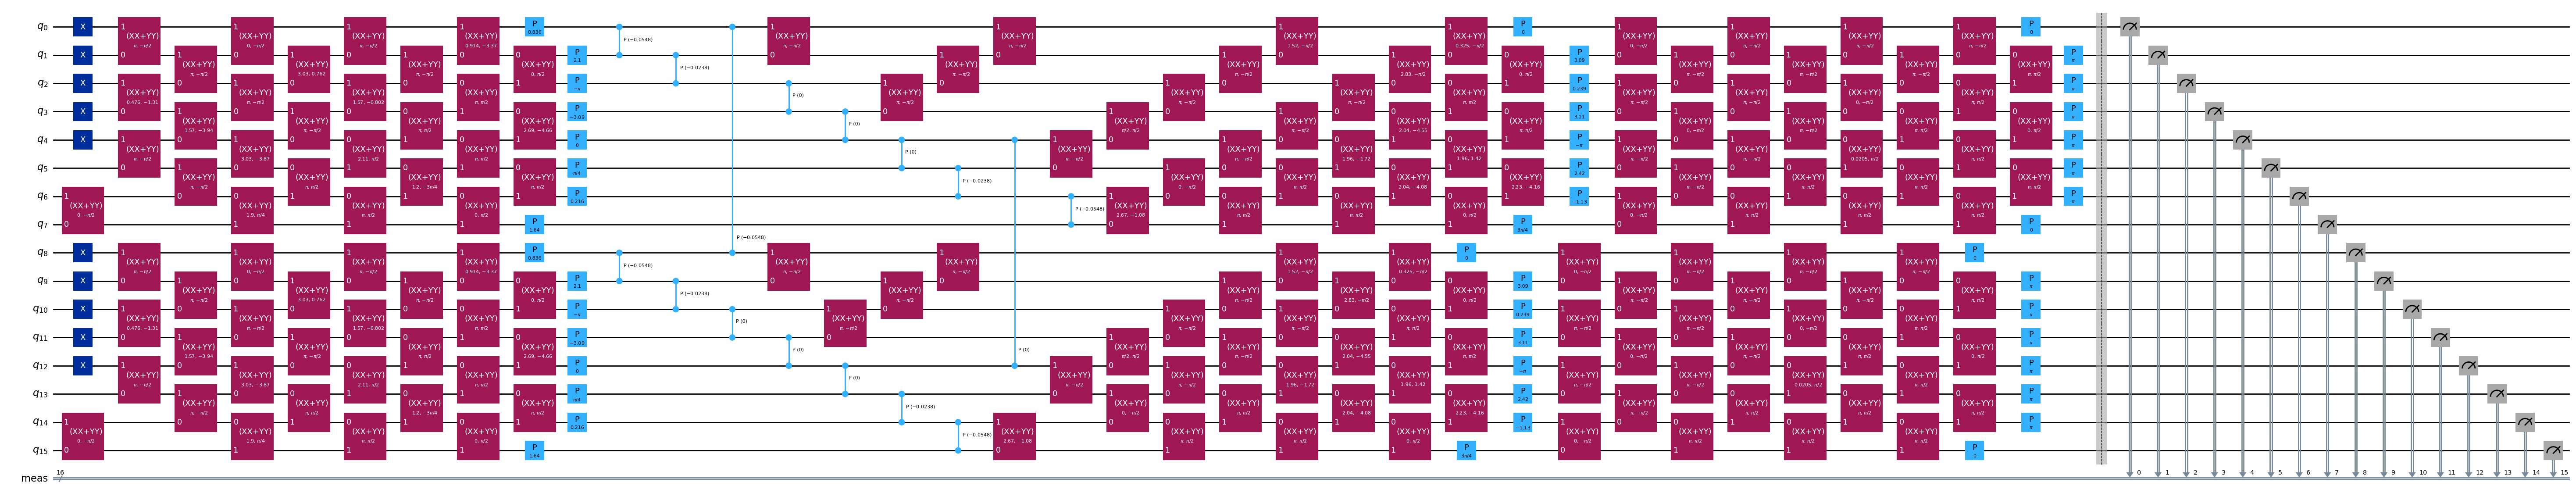

In [5]:
circuit.decompose(reps=2).draw('mpl',fold=-1)

In [6]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()

backend = service.backend("ibm_strasbourg")

In [7]:
def heavy_hex_layout(cm,norbs):
    '''
    Maps to 127 heavy-hex device automatically given the number of orbitals

    parameters
    ----------
    cm: qiskit.transpiler.coupling.CouplingMap
        CouplingMap of the device
    norbs: int
        Number of spatial orbitals
        
    returns
    -------
    spin_a_layout: list
        Qubits for the alpha orbitals

    spin_b_layout: list
        Qubits for the beta orbitals
        
    '''
    G=nx.Graph(list(cm.get_edges()))
    alpha_path = []
    beta_path = []
    connectors = []
    # c: connector (coupling term)
    # a: alpha
    # b: beta
    for c in np.arange(0, 127, 21):
        if c == 0:
            c = 1
        edges = list(G.edges(c))
        if len(edges) >= 2:
            a = edges[0][1]
            b = edges[1][1]
            alpha_path.append(a)
            beta_path.append(b)
            connectors.append(c)
        else:
            print(f"Node {c} has fewer than 2 edges.")
    
    # (starting linker, ending linker)
    alpha_pairs = [(alpha_path[i], alpha_path[i+1]) for i in range(len(alpha_path)-1)]
    beta_pairs = [(beta_path[i], beta_path[i+1]) for i in range(len(beta_path)-1)]
    
    alpha_edge =[nx.shortest_path(G,u,v) for u,v in alpha_pairs]
    beta_edge =[nx.shortest_path(G,u,v) for u,v in beta_pairs]
    
    alpha_path_set = list(set(sum(alpha_edge,[])))
    beta_path_set = list(set(sum(beta_edge,[])))   
    
    # Need to include the number of spatial orbitals
    spin_a_layout, spin_b_layout = alpha_path_set[:norbs], beta_path_set[:norbs]
    return spin_a_layout, spin_b_layout

spin_a_layout, spin_b_layout = heavy_hex_layout(backend.coupling_map,num_orbitals)
initial_layout = spin_a_layout + spin_b_layout

In [8]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# spin_a_layout = [0, 14, 18, 19, 20, 33, 39, 40, 41, 53, 60, 61, 62, 72, 81, 82]
# spin_b_layout = [2, 3, 4, 15, 22, 23, 24, 34, 43, 44, 45, 54, 64, 65, 66, 73]
# initial_layout = spin_a_layout + spin_b_layout

pass_manager = generate_preset_pass_manager(
    optimization_level=3, backend=backend, initial_layout=initial_layout
)

# without PRE_INIT passes
isa_circuit = pass_manager.run(circuit)
print(f"Gate counts (w/o pre-init passes): {isa_circuit.count_ops()}")

# with PRE_INIT passes
# We will use the circuit generated by this pass manager for hardware execution
pass_manager.pre_init = ffsim.qiskit.PRE_INIT
isa_circuit = pass_manager.run(circuit)
print(f"Gate counts (w/ pre-init passes): {isa_circuit.count_ops()}")

Gate counts (w/o pre-init passes): OrderedDict([('rz', 992), ('sx', 660), ('ecr', 302), ('x', 60), ('measure', 16), ('barrier', 1)])
Gate counts (w/ pre-init passes): OrderedDict([('rz', 599), ('sx', 456), ('ecr', 178), ('x', 29), ('measure', 16), ('barrier', 1)])


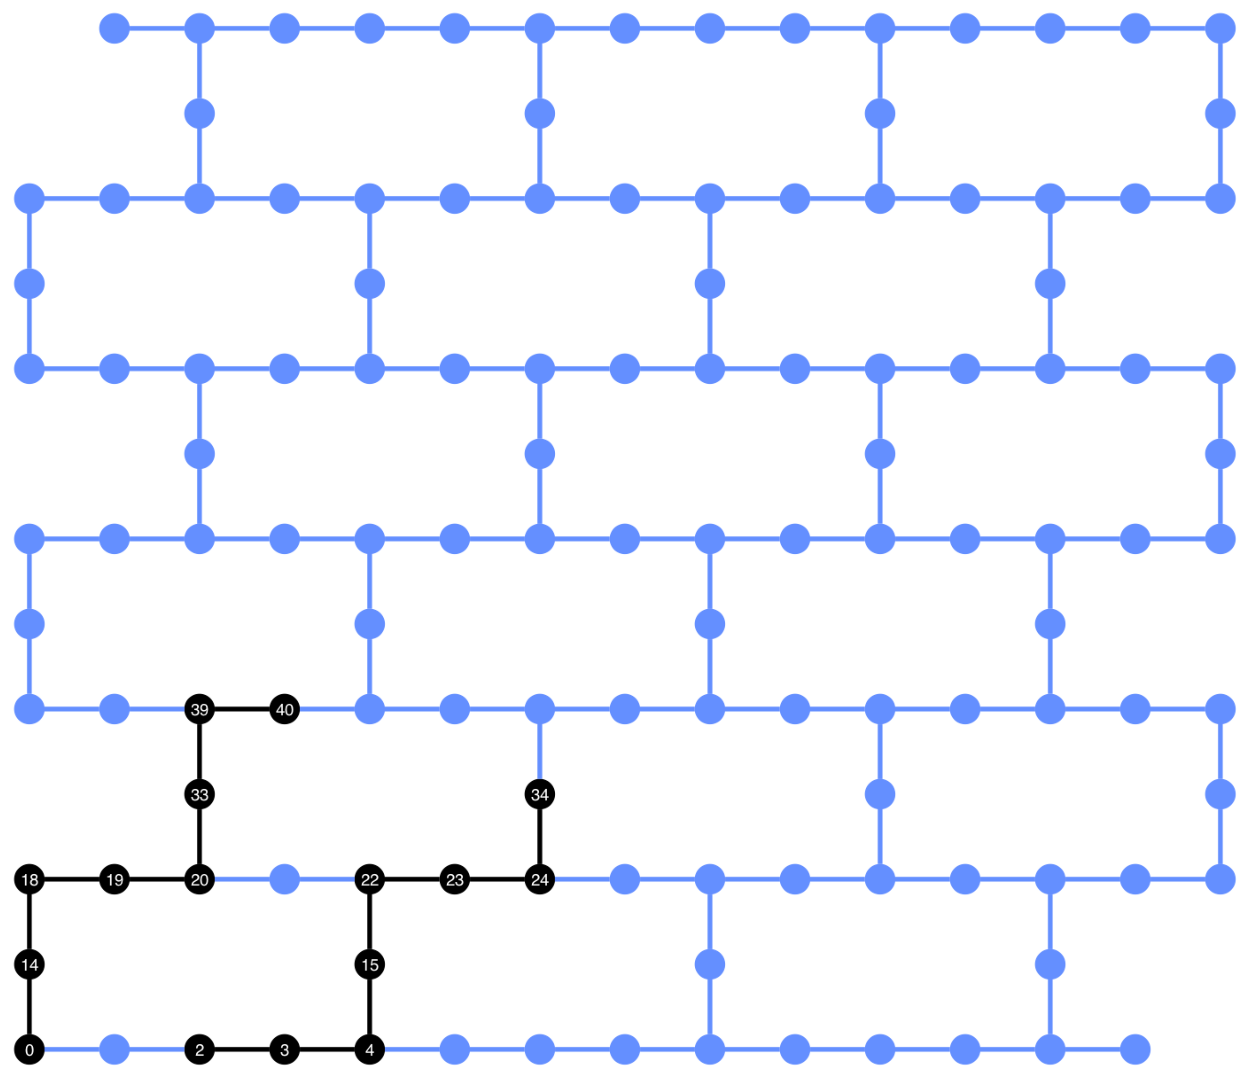

In [9]:
from qiskit.visualization import plot_circuit_layout

plot_circuit_layout(isa_circuit, backend,'physical')


In [10]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

# sampler = Sampler(mode=backend)
# job = sampler.run([isa_circuit], shots=10_000)

job = service.job('d11h9w7v3z500082dp30')

In [11]:
primitive_result = job.result()
pub_result = primitive_result[0]
counts = pub_result.data.meas.get_counts()

In [12]:
from qiskit_addon_sqd.counts import counts_to_arrays

# Convert counts into bitstring and probability arrays
bitstring_matrix_full, probs_arr_full = counts_to_arrays(counts)

In [13]:
import numpy as np
from qiskit_addon_sqd.configuration_recovery import recover_configurations
from qiskit_addon_sqd.fermion import solve_fermion
from qiskit_addon_sqd.subsampling import postselect_and_subsample

rng = np.random.default_rng(12345)

# SQD options
iterations = 4

# Eigenstate solver options
n_batches = 5
samples_per_batch = 20000
max_davidson_cycles = 200

# Self-consistent configuration recovery loop
e_hist = np.zeros((iterations, n_batches))  # energy history
s_hist = np.zeros((iterations, n_batches))  # spin history
occupancy_hist = []
avg_occupancy = None
for i in range(iterations):
    print(f"Starting configuration recovery iteration {i}")
    # On the first iteration, we have no orbital occupancy information from the
    # solver, so we just post-select from the full bitstring set based on hamming weight.
    if avg_occupancy is None:
        bs_mat_tmp = bitstring_matrix_full
        probs_arr_tmp = probs_arr_full

    # If we have average orbital occupancy information, we use it to refine the full set of noisy configurations
    else:
        bs_mat_tmp, probs_arr_tmp = recover_configurations(
            bitstring_matrix_full,
            probs_arr_full,
            avg_occupancy,
            num_elec_a,
            num_elec_b,
            rand_seed=rng,
        )

    # Throw out configurations with incorrect particle number in either the spin-up or spin-down systems
    batches = postselect_and_subsample(
        bs_mat_tmp,
        probs_arr_tmp,
        hamming_right=num_elec_a,
        hamming_left=num_elec_b,
        samples_per_batch=samples_per_batch,
        num_batches=n_batches,
        rand_seed=rng,
    )

    # Run eigenstate solvers in a loop. This loop should be parallelized for larger problems.
    e_tmp = np.zeros(n_batches)
    s_tmp = np.zeros(n_batches)
    occs_tmp = []
    coeffs = []
    for j in range(n_batches):
        energy_sci, coeffs_sci, avg_occs, spin = solve_fermion(
            batches[j],
            hcore,
            eri,
            open_shell=open_shell,
            spin_sq=spin_sq,
            max_davidson=max_davidson_cycles,
        )
        energy_sci += nuclear_repulsion_energy
        e_tmp[j] = energy_sci
        s_tmp[j] = spin
        occs_tmp.append(avg_occs)
        coeffs.append(coeffs_sci)

    # Combine batch results
    avg_occupancy = np.mean(occs_tmp, axis=0)

    # Track optimization history
    e_hist[i, :] = e_tmp
    s_hist[i, :] = s_tmp
    occupancy_hist.append(avg_occupancy)

Starting configuration recovery iteration 0
Starting configuration recovery iteration 1
Starting configuration recovery iteration 2
Starting configuration recovery iteration 3


In [21]:
nuclear_repulsion_energy

-76.43855887763556

In [22]:
for i in range(8):
    print(hcore[i,i])

-6.445996205390804
-5.0642665803366995
-5.3208204812968924
-5.3208204812968924
-5.062181713311548
-4.949736227938508
-4.949736227938508
-4.8008613988903015


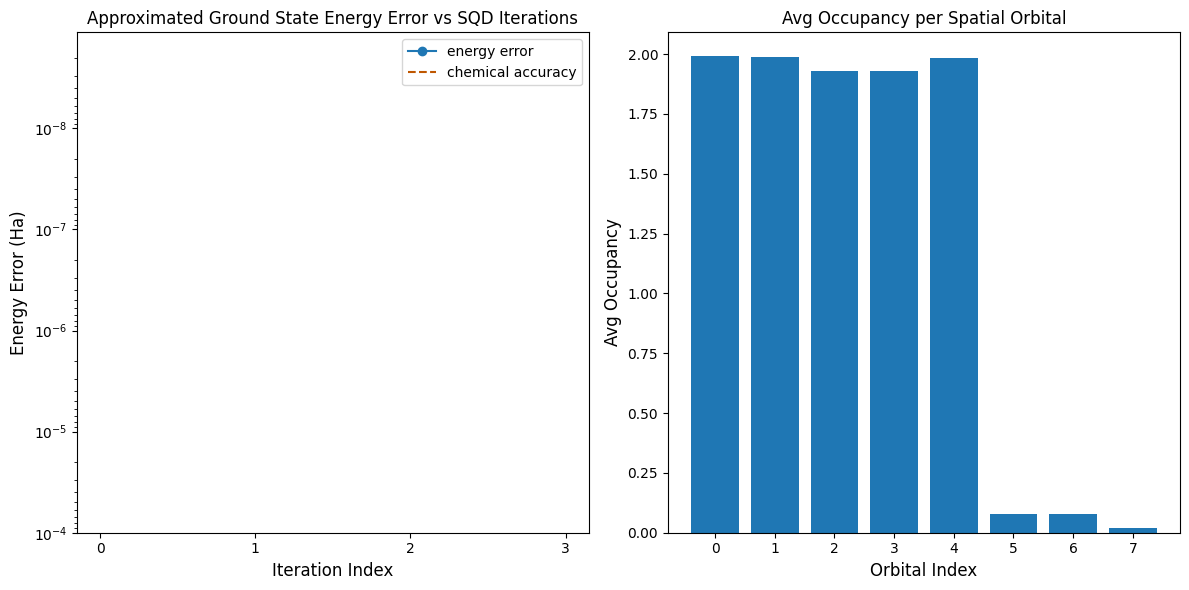

In [14]:
import matplotlib.pyplot as plt

# Data for energies plot
x1 = range(iterations)
e_diff = [abs(np.min(energies) - casci_e) for energies in e_hist]
yt1 = [1.0, 1e-1, 1e-2, 1e-3, 1e-4]

# Chemical accuracy (+/- 1 milli-Hartree)
chem_accuracy = 0.001

# Data for avg spatial orbital occupancy
y2 = occupancy_hist[-1][0] + occupancy_hist[-1][1]
x2 = range(len(y2))

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot energies
axs[0].plot(x1, e_diff, label="energy error", marker="o")
axs[0].set_xticks(x1)
axs[0].set_xticklabels(x1)
axs[0].set_yticks(yt1)
axs[0].set_yticklabels(yt1)
axs[0].set_yscale("log")
axs[0].set_ylim(1e-4)
axs[0].axhline(y=chem_accuracy, color="#BF5700", linestyle="--", label="chemical accuracy")
axs[0].set_title("Approximated Ground State Energy Error vs SQD Iterations")
axs[0].set_xlabel("Iteration Index", fontdict={"fontsize": 12})
axs[0].set_ylabel("Energy Error (Ha)", fontdict={"fontsize": 12})
axs[0].legend()

# Plot orbital occupancy
axs[1].bar(x2, y2, width=0.8)
axs[1].set_xticks(x2)
axs[1].set_xticklabels(x2)
axs[1].set_title("Avg Occupancy per Spatial Orbital")
axs[1].set_xlabel("Orbital Index", fontdict={"fontsize": 12})
axs[1].set_ylabel("Avg Occupancy", fontdict={"fontsize": 12})

plt.tight_layout()
plt.show()